<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-04 | train loss 1.3492 acc 0.421 | val loss 1.2047 acc 0.385 *


[AlexNet] Epoch   2/100 | LR: 1.00e-04 | train loss 1.1680 acc 0.396 | val loss 1.0334 acc 0.527 *


[AlexNet] Epoch   3/100 | LR: 1.00e-04 | train loss 1.0710 acc 0.474 | val loss 1.0492 acc 0.444


[AlexNet] Epoch   4/100 | LR: 1.00e-04 | train loss 1.0973 acc 0.473 | val loss 1.0774 acc 0.561


...

[AlexNet] Epoch  96/100 | LR: 1.00e-10 | train loss 0.5514 acc 0.706 | val loss 0.5517 acc 0.766


[AlexNet] Epoch  97/100 | LR: 1.00e-10 | train loss 0.5635 acc 0.702 | val loss 0.5517 acc 0.766


[AlexNet] Epoch  98/100 | LR: 1.00e-10 | train loss 0.5612 acc 0.706 | val loss 0.5517 acc 0.766


[AlexNet] Epoch  99/100 | LR: 1.00e-10 | train loss 0.5465 acc 0.697 | val loss 0.5517 acc 0.766


[AlexNet] Epoch 100/100 | LR: 1.00e-10 | train loss 0.5523 acc 0.715 | val loss 0.5517 acc 0.766

[AlexNet] Restored best checkpoint (val loss = 0.5430)


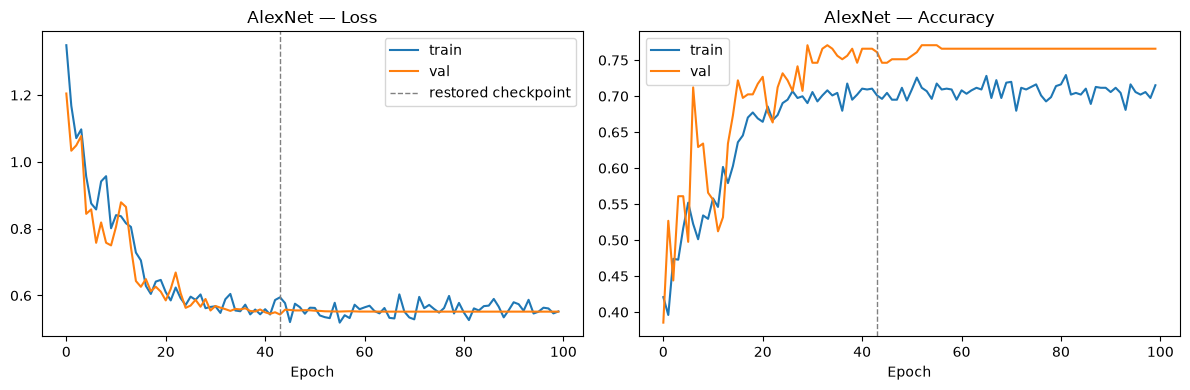

In [4]:
# No early stopping (patience=None): from random init AlexNet can sit on a
# ~ln(4) loss plateau for many epochs before it starts learning, and noisy
# val loss during that plateau made early stopping quit too soon.
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, None, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.523


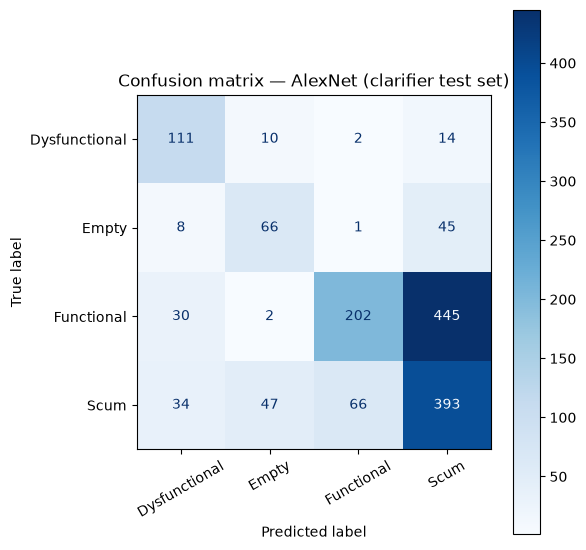

               precision    recall  f1-score   support

Dysfunctional      0.607     0.810     0.694       137
        Empty      0.528     0.550     0.539       120
   Functional      0.745     0.297     0.425       679
         Scum      0.438     0.728     0.547       540

     accuracy                          0.523      1476
    macro avg      0.580     0.596     0.551      1476
 weighted avg      0.602     0.523     0.504      1476



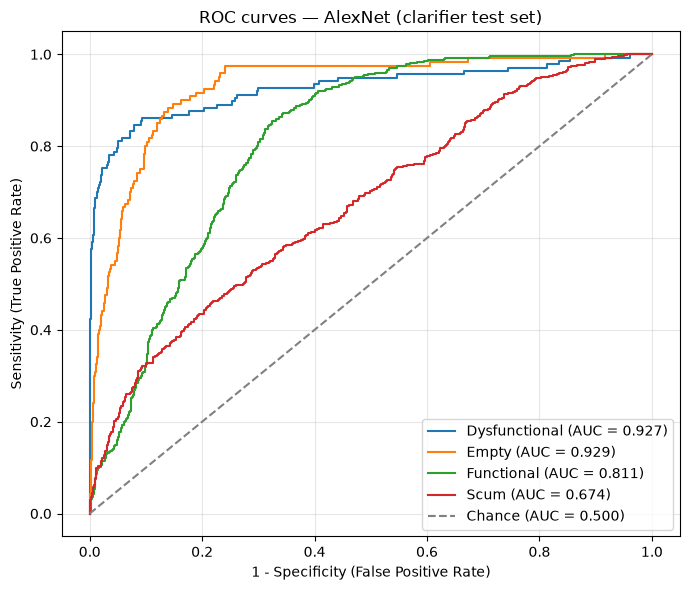

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.927
  Empty          : 0.929
  Functional     : 0.811
  Scum           : 0.674

Mean AUC (over 4/4 classes with test examples): 0.835


(np.float64(0.5230352303523035),
 {'Dysfunctional': 0.9271708378079294,
  'Empty': 0.9285521140609637,
  'Functional': 0.8112528018360458,
  'Scum': 0.6740622032288699})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/clarifier_aug/results_clarifier_alexnet_CapeFlats.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
